In [1]:
from sklearn.datasets import load_iris
import pandas as pd

In [2]:
iris=load_iris()
pd.set_option("display.max_columns", None)
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species")
print("X shape:", X.shape)
print("y shape:", y.shape)
print(X.head(15))
print(y.head(15))
MissingVals=X.isna().sum()
print(MissingVals)

X shape: (150, 4)
y shape: (150,)
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                 5.1               3.5                1.4               0.2
1                 4.9               3.0                1.4               0.2
2                 4.7               3.2                1.3               0.2
3                 4.6               3.1                1.5               0.2
4                 5.0               3.6                1.4               0.2
5                 5.4               3.9                1.7               0.4
6                 4.6               3.4                1.4               0.3
7                 5.0               3.4                1.5               0.2
8                 4.4               2.9                1.4               0.2
9                 4.9               3.1                1.5               0.1
10                5.4               3.7                1.5               0.2
11                4.8               3.4   

In [3]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (120, 4)
X_test : (30, 4)
y_train: (120,)
y_test : (30,)


In [5]:
print("Train class counts:")
print(y_train.value_counts())

print("\nTest class counts:")
print(y_test.value_counts())


Train class counts:
species
0    40
2    40
1    40
Name: count, dtype: int64

Test class counts:
species
0    10
2    10
1    10
Name: count, dtype: int64


Tree based models:-

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

Decesion tree classifier:-

In [7]:
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)
y_pred_dt = dt_clf.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nDecision Tree Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9333333333333333

Decision Tree Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



Random Forest:-

In [8]:
rf_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9

Random Forest Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.82      0.90      0.86        10
           2       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



Gradient Boosting

In [9]:
gb_clf = GradientBoostingClassifier(random_state=42)
gb_clf.fit(X_train, y_train)
y_pred_gb = gb_clf.predict(X_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nGradient Boosting Report:\n", classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.9666666666666667

Gradient Boosting Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



KNN:-

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

Creating

In [11]:
values=list(range(1,22)) #Here I am defining number of samples to be taken (1-21), and storing it in a list
accuracy_values=[] #Empty list to store all the accuracy for me to in the end just do a print("max(accuracy_values)") to print the maximum accuracy by knn

In [13]:
for i in values:
  knnPipeline=Pipeline(steps=[("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=i))])
  #In the aforementioned line, I make a pipeline named knnPipeline, define the 1st step as standard scaling then KNeighborsClassifier and consider n_neighbors as i.
  knnPipeline.fit(X_train,y_train)
  #In the aforementioned line, LEARN from X_train and y_train
  y_pred=knnPipeline.predict(X_test)
  newAccuracyValue=accuracy_score(y_test,y_pred)
  accuracy_values.append(newAccuracyValue)


The best Accuracy predicted by knn:-

In [18]:
best_accuracy = max(accuracy_values)
best_k = values[accuracy_values.index(best_accuracy)]
# print(accuracy_values)
print("Best k:", best_k)
print("Best accuracy:", best_accuracy)


Best k: 1
Best accuracy: 0.9666666666666667


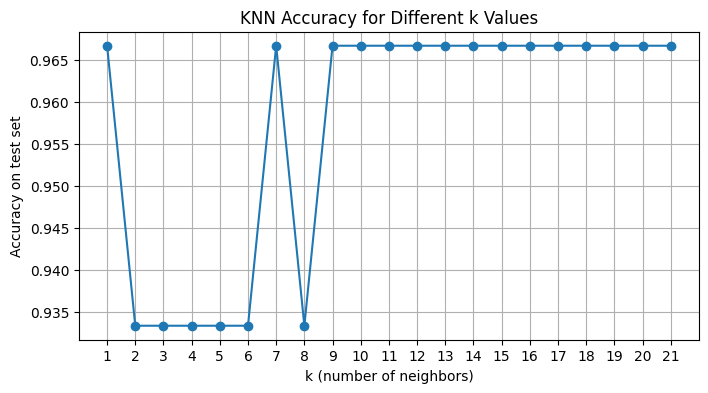

In [20]:
plt.figure(figsize=(8, 4))
plt.plot(values, accuracy_values, marker="o")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Accuracy on test set")
plt.title("KNN Accuracy for Different k Values")
plt.xticks(values)
plt.grid(True)
plt.show()

In [22]:
bestPipeline=Pipeline(steps=[("scaler",StandardScaler()),("new_knn",KNeighborsClassifier(n_neighbors=best_k))])
bestPipeline.fit(X_train, y_train)
y_pred_knn = bestPipeline.predict(X_test)
from sklearn.metrics import classification_report, accuracy_score
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nKNN Classification Report:\n", classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.9666666666666667

KNN Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.91      1.00      0.95        10
           2       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score
summary = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "KNN (k=1)"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_knn)
    ],
    "Precision (macro)": [
        precision_score(y_test, y_pred_dt, average="macro"),
        precision_score(y_test, y_pred_rf, average="macro"),
        precision_score(y_test, y_pred_gb, average="macro"),
        precision_score(y_test, y_pred_knn, average="macro")
    ],
    "Recall (macro)": [
        recall_score(y_test, y_pred_dt, average="macro"),
        recall_score(y_test, y_pred_rf, average="macro"),
        recall_score(y_test, y_pred_gb, average="macro"),
        recall_score(y_test, y_pred_knn, average="macro")
    ],
    "F1 (macro)": [
        f1_score(y_test, y_pred_dt, average="macro"),
        f1_score(y_test, y_pred_rf, average="macro"),
        f1_score(y_test, y_pred_gb, average="macro"),
        f1_score(y_test, y_pred_knn, average="macro")
    ]
})

summary


,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,Decision Tree,0.933333,0.933333,0.933333,0.933333
1,Random Forest,0.900000,0.902357,0.900000,0.899749
2,Gradient Boosting,0.966667,0.969697,0.966667,0.966583
3,KNN (k=1),0.966667,0.969697,0.966667,0.966583
